In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

df = pd.read_parquet('../../dataset/data.parquet', engine='fastparquet')
#df = df[df['Desired_Savings'] > 0].copy()

df['perc_nao_essenciais'] = (df['Eating_Out'] + df['Entertainment']) / df['Income']
df['perc_emprestimo'] = df['Loan_Repayment'] / df['Income']
df['Vulnerable'] = ((df['perc_emprestimo'] > 0.10).astype(int) + 
                    (df['perc_nao_essenciais'] > 0.085).astype(int) + 
                    ((df['Disposable_Income'] - df['Desired_Savings']) / df['Income'] < 0.10).astype(int) + 
                    (df['Potential_Savings_Groceries'] / df['Income'] > 0.08).astype(int) >= 2).astype(int)

df['Rent_Ratio'] = df['Rent'] / df['Income']
df['Healthcare_Ratio'] = df['Healthcare'] / df['Income']
df['Education_Ratio'] = df['Education'] / df['Income']
df['Groceries_Ratio'] = df['Groceries'] / df['Income']
df['Transport_Ratio'] = df['Transport'] / df['Income']
df['Utilities_Ratio'] = df['Utilities'] / df['Income']
df['Insurance_Ratio'] = df['Insurance'] / df['Income']



features_percentuais = [
    'Age', 
    'Dependents', 
    'Rent_Ratio', 
    'Healthcare_Ratio', 
    'Education_Ratio', 
    'Groceries_Ratio',
    'Transport_Ratio',
    'Utilities_Ratio',
    'Insurance_Ratio'
]

X = df[features_percentuais]
y = df['Vulnerable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)




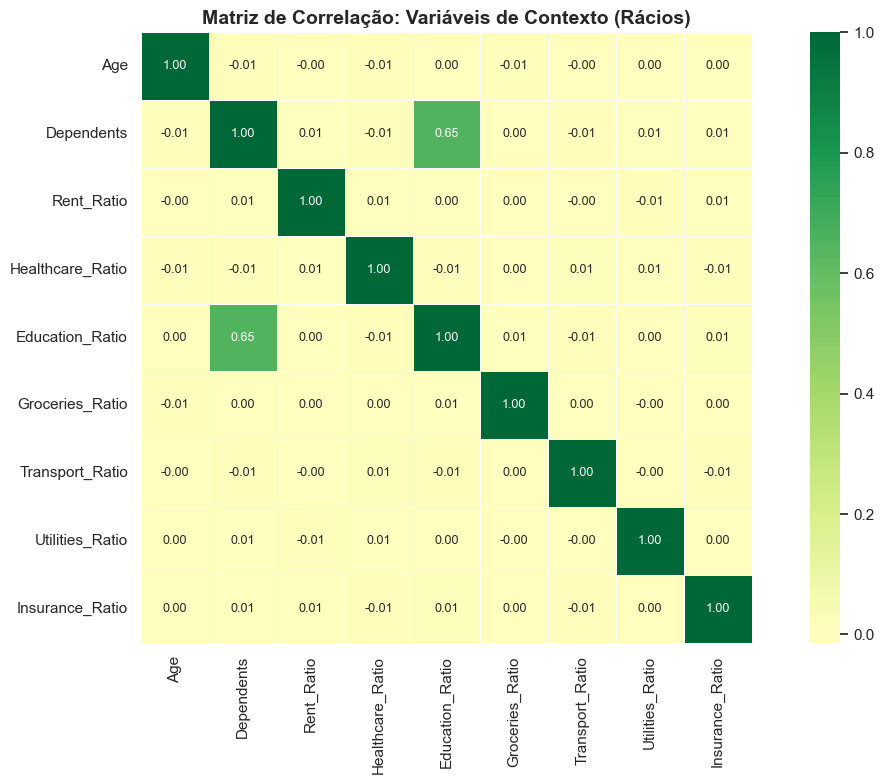


 ALERTA DE MULTICOLINEARIDADE (Correlação > 0.7 ou < -0.7) 
------------------------------------------------------------


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

features_percentuais = [
    'Age',
    'Dependents',
    'Rent_Ratio',
    'Healthcare_Ratio',
    'Education_Ratio',
    'Groceries_Ratio',
    'Transport_Ratio',
    'Utilities_Ratio',
    'Insurance_Ratio'
]

X_corr = df[features_percentuais]
corr_matrix = X_corr.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 9}
)
plt.title('Matriz de Correlação: Variáveis de Contexto (Rácios)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n ALERTA DE MULTICOLINEARIDADE (Correlação > 0.7 ou < -0.7) ")
print("------------------------------------------------------------")
for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if col != row and abs(corr_matrix.loc[row, col]) > 0.7:
            if list(corr_matrix.columns).index(row) > list(corr_matrix.columns).index(col):
                print(f"  {row} ↔ {col}: {corr_matrix.loc[row, col]:.2f}")

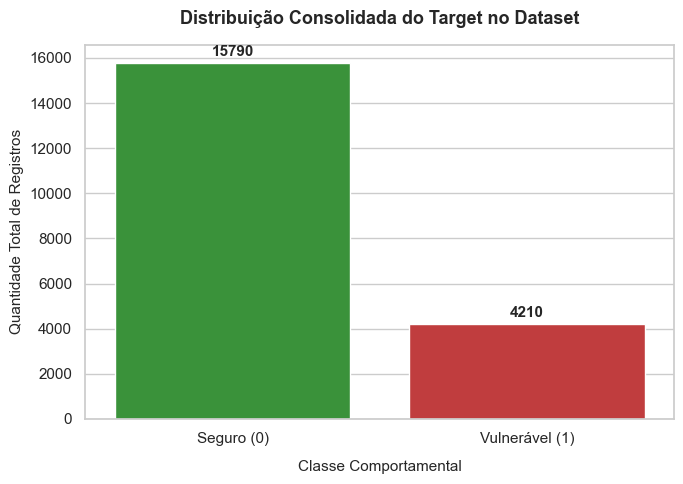

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))


ax = sns.countplot(
    x='Vulnerable', 
    data=df, 
    palette=['#2ca02c', '#d62728'], 
    hue='Vulnerable',
    legend=False
)


for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(
            f'{int(altura)}', 
            (p.get_x() + p.get_width() / 2., altura), 
            ha='center', 
            va='center', 
            xytext=(0, 8), 
            textcoords='offset points',
            fontweight='bold',
            fontsize=11
        )


plt.title('Distribuição Consolidada do Target no Dataset', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Classe Comportamental', fontsize=11, labelpad=10)
plt.ylabel('Quantidade Total de Registros', fontsize=11)
plt.xticks(ticks=[0, 1], labels=['Seguro (0)', 'Vulnerável (1)'], fontsize=11)

plt.tight_layout()
plt.show()


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, roc_auc_score

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
ratio = n_neg / n_pos

modelos = {
    'Regressão Logística': LogisticRegression(random_state=42, class_weight={0: 1, 1: ratio * 0.8}, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight={0: 1, 1: ratio * 0.8}, n_estimators=100),
    'Gradient Boosting-0.6': GradientBoostingClassifier(random_state=42, subsample=0.6),
    'Gradient Boosting-0.7': GradientBoostingClassifier(random_state=42, subsample=0.7),
    'Gradient Boosting-0.8': GradientBoostingClassifier(random_state=42, subsample=0.8),
    'Gradient Boosting-0.9': GradientBoostingClassifier(random_state=42, subsample=0.9),
    'XGBoost': XGBClassifier(random_state=42, scale_pos_weight=ratio * 0.8, min_child_weight=5, max_depth=5),
    'SVM': make_pipeline(StandardScaler(), SVC(probability=True, random_state=42, class_weight={0: 1, 1: ratio * 0.8})),
    'CatBoost': CatBoostClassifier(random_state=42, class_weights=[1, ratio * 0.8], verbose=0)
}

print(f"🔄 Treinando {len(modelos)} algoritmos de alta performance...\n")

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    y_prob = modelo.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)

    print(f"{'='*60}")
    print(f" ALGORITMO: {nome}")
    print(f" AUC-ROC: {auc:.4f}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, target_names=['Seguro', 'Vulnerável']))
    print("\n")

🔄 Treinando 9 algoritmos de alta performance...



 ALGORITMO: Regressão Logística
 AUC-ROC: 0.6641
              precision    recall  f1-score   support

      Seguro       0.83      0.80      0.81      3158
  Vulnerável       0.33      0.38      0.35       842

    accuracy                           0.71      4000
   macro avg       0.58      0.59      0.58      4000
weighted avg       0.72      0.71      0.72      4000



 ALGORITMO: Random Forest
 AUC-ROC: 0.6404
              precision    recall  f1-score   support

      Seguro       0.79      0.99      0.88      3158
  Vulnerável       0.27      0.01      0.02       842

    accuracy                           0.79      4000
   macro avg       0.53      0.50      0.45      4000
weighted avg       0.68      0.79      0.70      4000



 ALGORITMO: Gradient Boosting-0.6
 AUC-ROC: 0.6591
              precision    recall  f1-score   support

      Seguro       0.79      1.00      0.88      3158
  Vulnerável       0.58      0.01      0.02       842

    accuracy                       